In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import json
from langchain_groq import ChatGroq

In [4]:
load_dotenv()

True

In [5]:
class SentimentSchema(BaseModel):
  sentiment: Literal['positive','negative'] = Field(..., description="The sentiment of the review")

In [6]:
class ReviewState(TypedDict):
  review: str
  sentiment:  Literal['positive','negative']
  diagnosis: dict
  response: str

In [17]:
model = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

In [19]:


# def analyze_sentiment(state: ReviewState) -> SentimentSchema:
#     prompt = f"""
# You are a sentiment classifier.

# Return ONLY valid JSON in this exact format:
# {{"sentiment": "positive" | "negative" }}

# Review:
# {state["review"]}
# """

#     response = model.invoke(prompt)

#     # Parse manually (LangGraph style)
#     data = json.loads(response.content)

#     # Optional: validate with Pydantic
#     parsed = SentimentSchema(**data)

#     return {
#         "sentiment": parsed.sentiment
#     }
structure_model = model.with_structured_output(SentimentSchema)


In [20]:


def analyze_sentiment(state: ReviewState) -> SentimentSchema:
    prompt = f"""
You are a sentiment classifier.


Review:
{state["review"]}
"""

    response = structure_model.invoke(prompt)


    return {
        "sentiment": response.sentiment
    }

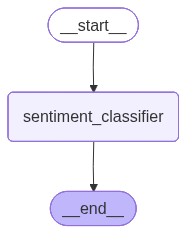

In [21]:
graph = StateGraph(ReviewState)

graph.add_node('sentiment_classifier', analyze_sentiment)

graph.add_edge(START, 'sentiment_classifier')
graph.add_edge('sentiment_classifier', END)
workflow = graph.compile()
workflow

In [22]:
inital_state = {
    "review": "The product is amazing!",
}
workflow.invoke(inital_state)

{'review': 'The product is amazing!', 'sentiment': 'positive'}